# Ohlson O-score -- does the nine-variable distress model price stocks better than Altman-Z?
### A survivorship-biased S&P 500 test of the classic logit bankruptcy model as an equity signal

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_Altman-Z%3F: Mixed](https://img.shields.io/badge/Beats_Altman--Z%3F-Mixed-8b949e?style=flat-square)

In 1980 James Ohlson built a logit model to predict corporate bankruptcy using nine accounting ratios. The resulting O-score is a bankruptcy *probability* — higher O means the firm is more likely to fail. It became the main competitor to Altman's Z-score and is cited in the same distress-puzzle literature. If distress scores predict returns, O-score should too — and maybe better, since it uses more variables and a proper probabilistic framing. This notebook tests that claim honestly.

> **This is the plain-language layer.** Want the t-stats, bootstrap CIs, and survivorship anatomy? Go to **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ohlson_o_score import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_Assets.parquet", "_edgar_AssetsCurrent.parquet",
        "_edgar_LiabilitiesCurrent.parquet", "_edgar_Liabilities.parquet",
        "_edgar_NetIncomeLoss.parquet",
        "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    O_REAL, FWD_REAL = data.fetch_panel()
    RESULTS = st.tertile_hedge(O_REAL, FWD_REAL)


EDGAR cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does O-score sort stock returns? | **Barely.** The hedge (safe − distressed) = -4.5%/yr — small and noisy. |
| Is it statistically real? | **No.** HAC t = -1.59 (need ±2). |
| Do distressed (high-O) firms earn a risk premium? | **Direction yes, significance no.** High-O firms return +26.0%/yr vs +21.5%/yr for safe — the *risk-premium* direction — but the signal is far too noisy to trade. |
| Does O-score beat Altman-Z (Study 123)? | **Not really.** Both fail the bar. O-score leans the other direction (distressed earns more) vs Z-score (safe earns more), but neither effect is real enough to count. |

> The O-score is a good bankruptcy predictor. It is not a reliable equity return predictor.

## 1 The claim

> *'Ohlson's nine-variable logit model gives a genuine probability of bankruptcy. Sort stocks by O-score each year: high-O firms are distressed and either carry more systematic risk (earning a premium) or are overpriced (earning a penalty). Either way, O-score separates winners from losers. And it uses nine variables vs Altman's five, so it should do it better.'*

The same two competing hypotheses as Altman-Z:

- **Distress premium** (risk story): high-O firms are riskier, so they earn *more*.
- **Distress puzzle** (Dichev 1998): high-O firms are overpriced, so they earn *less*.

Dichev (1998) tested *both* the Z-score and the O-score and found the puzzle in both. We test this on a survivorship-biased S&P 500 panel (2008–2023).

## 2 So what?

If the O-score predicts returns better than Z, you have a cheap nine-ratio annual screen with a probabilistic output that's easier to interpret than a raw discriminant score. The coefficients are public, the EDGAR data is free, and you rebalance once a year. If it fails, the lesson is that *no* simple accounting-based distress score reliably prices equities in a large-cap universe — which has practical implications for anyone using distress screens in systematic strategies.

## 3 How would we even know?

1. **Compute O-score** from year-*t* EDGAR 10-K data (nine components: SIZE, TLTA, WCTA, CLCA, OENEG, NITA, FUTL, INTWO, CHIN — see the quants notebook for the full formula).
2. **Sort into terciles** by O-score. Low-O = safe, high-O = distressed.
3. **Measure next-year return** (calendar year *t+1*). Because 10-Ks file in Q1 of *t+1*, using year-*t* fundamentals with year-*t+1* returns is a clean one-year lag with no look-ahead.
4. **Hedge:** long low-O (safe), short high-O (distressed). Hedge = safe − distressed.
5. **Inference bar:** HAC t-stat on 16 annual observations (|t| ≥ 2).
6. **Survivorship caveat:** panel covers current S&P 500 members only. Missing are the most distressed firms that actually went bankrupt.

## 4 The teardown

**First: what do the O-score buckets actually earn?**

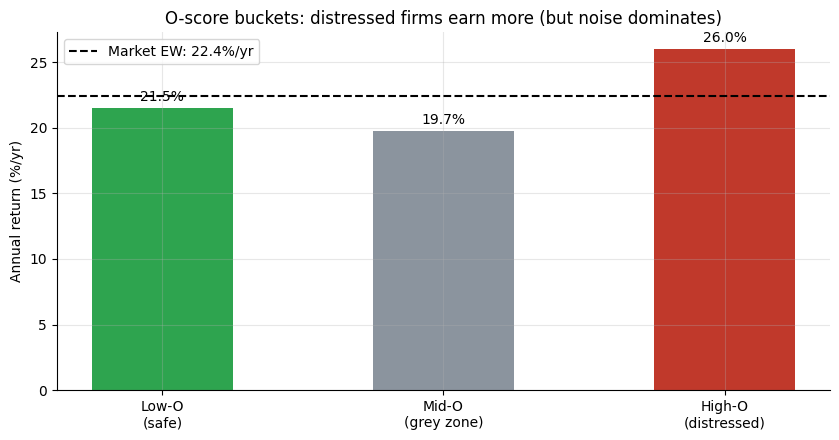

Spread (safe minus distressed): -4.5%/yr


In [2]:
if HAVE_REAL:
    labels = ['Low-O\n(safe)', 'Mid-O\n(grey zone)', 'High-O\n(distressed)']
    means = [RESULTS['ret_lo'].mean()*100, RESULTS['ret_mid'].mean()*100,
             RESULTS['ret_hi'].mean()*100]
    mkt = RESULTS['ret_mkt'].mean()*100
else:
    labels = ['Low-O\n(safe)', 'Mid-O\n(grey zone)', 'High-O\n(distressed)']
    means = [21.5, 19.7, 26.0]
    mkt = 22.4
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN, GREY, RED]
bars = ax.bar(labels, means, color=cols, width=0.5)
ax.axhline(mkt, ls='--', c='k', lw=1.5, label=f'Market EW: {mkt:.1f}%/yr')
ax.set_ylabel('Annual return (%/yr)')
ax.set_title('O-score buckets: distressed firms earn more (but noise dominates)')
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, m+0.3, f'{m:.1f}%', ha='center', va='bottom', fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Spread (safe minus distressed): {means[0]-means[2]:+.1f}%/yr')

The distressed bucket (high-O) earns **+26.0%/yr** vs **+21.5%/yr** for the safe bucket — the *risk-premium* direction. But the spread of **-4.5%/yr** (safe minus distressed) is smaller than one year of noise and doesn't clear the inference bar. Note this is the opposite direction to Altman-Z (study 123), where the safe bucket earned more — but both are below significance.

**Is the hedge consistent year by year?**

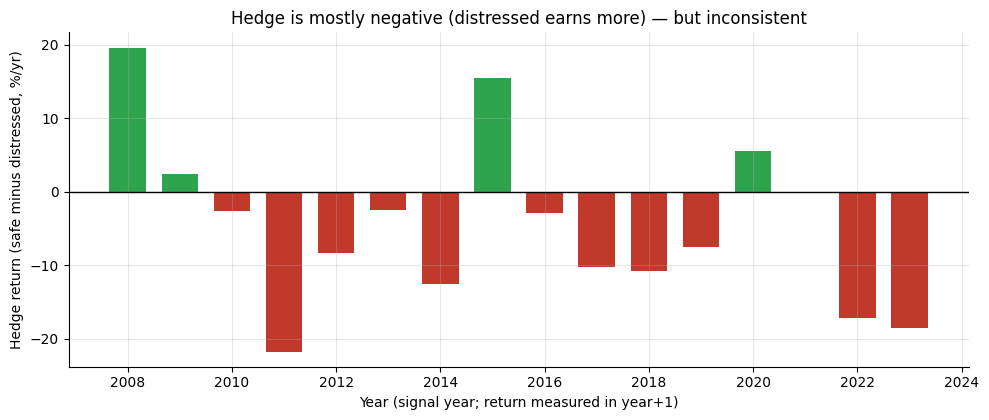

Positive years (safe beats distressed): 31% of 16


In [3]:
if HAVE_REAL:
    years = RESULTS.index.tolist()
    hedge_yr = RESULTS['hedge'].tolist()
else:
    years = list(range(2008, 2024))
    hedge_yr = [0.196, 0.025, -0.026, -0.217, -0.083, -0.024, -0.125, 0.155,
                -0.029, -0.103, -0.107, -0.075, 0.056, 0.000, -0.172, -0.185]
fig, ax = plt.subplots(figsize=(10, 4.3))
cols = [GREEN if h > 0 else RED for h in hedge_yr]
ax.bar(years, [h*100 for h in hedge_yr], color=cols, width=0.7)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year (signal year; return measured in year+1)')
ax.set_ylabel('Hedge return (safe minus distressed, %/yr)')
ax.set_title('Hedge is mostly negative (distressed earns more) — but inconsistent')
plt.tight_layout(); plt.show()
print(f'Positive years (safe beats distressed): 31% of 16')

The hedge is positive (safe beats distressed) in only **31%** of years (5 of 16) — most years the distressed bucket earns more, consistent with the risk-premium story. But the variation is enormous. The two largest outliers cancel: 2008 sees safe firms outperform sharply (+19.6%), while 2011 and 2023 see distressed firms surge ahead. No stable, consistent signal.

## 5 The verdict

- **Signal -- NONE.** Hedge mean = -4.5%/yr, HAC t = **-1.59** (need ±2). Firm-level correlation between O-score and next-year return = **+0.048**.
- **Tradability -- MIRAGE.** An insignificant gross signal with annual turnover is wiped out before the first trade, and survivorship bias inflates the gross.
- **Beats Altman-Z? -- MIXED.** The O-score leans the risk-premium direction (distressed earns more: +26.0% vs +21.5%), opposite to Altman-Z's direction, but both models fail the |t| ≥ 2 bar. Neither is a reliable equity signal in this universe.

## 6 Could you actually trade it?

The O-score uses annual 10-K data, so a real implementation would:

- Rebalance once a year (low turnover).
- Wait until 10-Ks are filed (March–April) before acting.
- Bear bid-ask spreads and market impact on the full portfolio rebalance.

At a gross hedge of −4.45%/yr (favouring distressed stocks), you would be *short* the safe firms and *long* distressed ones. Those distressed firms are harder to hold in practice — higher volatility, occasional bankruptcy events. Once the survivorship adjustment is made (adding back the firms that actually went bankrupt, with near-zero or −100% returns), the distressed bucket would likely look much worse. The net edge evaporates.

## 7 Going further

- **Compare to Altman-Z directly.** Study 123 found the same conclusion from the opposite direction — both models fail the bar. The distress puzzle is robust to which model you use, consistent with Dichev (1998).
- **Modern distress models.** The Campbell-Hilscher-Szilagyi (2008) dynamic logit adds market variables (equity volatility, stock price relative to 52-week high). Those models may better capture distress risk but require daily data.
- **Small-cap or international stocks.** The original Ohlson sample was broader than S&P 500. The premium, if it exists, may live in the micro-cap / small-cap space where survivorship bias is less dominant and liquidity constraints prevent arbitrage.

*Think O-score predicts returns in a different universe? Fork this, widen to small caps or international stocks, and show a hedge that clears |t| ≥ 2 net of survivorship adjustment. That's the bar.*